In [1]:
# Mobility Heatmap Analysis Notebook
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle as pkl
from shapely.geometry import Point, box
from geolib import geohash as geolib
import h3
import shapely.geometry as geometry
import os


# --------------------------------------------------------
# Parameters
# --------------------------------------------------------
keep_only_ch = False # Whether to keep only data in Switzerland (based on geohashes)


# -------------------------------------------------------
# Load Data
# -------------------------------------------------------

paths = pd.read_csv("data/all_paths_128.csv", sep=";")
movements = pd.read_csv("data/all_movements_138.csv", sep=";")
steps = pd.read_csv("data/all_steps_2.csv", sep=";")
lifestyles = pd.read_csv("data/lifestyles.csv", sep=",")

# -------------------------------------------------------
# Load / init cache
# -------------------------------------------------------
try:
    geohashes_cache = pkl.load(open("./geohashes_to_coords.pkl", "rb"))
except FileNotFoundError:
    geohashes_cache = {}

# Read geohashes to coordinates mapping (dataframe with columns: geohash, latitude, longitude)
geo_to_coords = pd.read_pickle('geohashes_to_coords.pkl')

# Function to complete geo_to_coords with missing geohashes
def complete_geo_to_coords(geo_to_coords, geohashes):
    missing_geohashes = set(geohashes) - set(geo_to_coords['geohash'])
    new_rows = []
    for gh in missing_geohashes:
        try:
            lat, lon = geolib.decode(gh)
            new_rows.append({'geohash': gh, 'latitude': lat, 'longitude': lon})
        except Exception as e:
            print(f"Error decoding geohash {gh}: {e}")
    if new_rows:
        geo_to_coords = pd.concat([geo_to_coords, pd.DataFrame(new_rows)], ignore_index=True)
        geo_to_coords.to_pickle('geohashes_to_coords.pkl') # Save to file
    return geo_to_coords

In [2]:
import rasterio

def polygon_vertex_centroid_points(poly):
    """
    Returns list of (x,y) = (lon,lat) points: polygon exterior vertices + centroid.
    """
    coords = list(poly.exterior.coords)[:-1]  # drop closing duplicate
    c = poly.centroid
    coords.append((c.x, c.y))                 # (lon,lat)
    return coords

def add_elevation_to_gdf(gdf, dem_path):
    """
    Adds average elevation to each polygon in gdf by sampling DEM at polygon vertices + centroid.
    Returns new GeoDataFrame with 'avg_elevation' column.
    """
    all_points = []
    row_slices = []  # (start, end) indices into all_points

    # Open DEM first so we can safely reproject if needed
    with rasterio.open(dem_path) as src:
        # Reproject geometries to DEM CRS if needed
        gdf_src = gdf.to_crs(src.crs) if (gdf.crs != src.crs) else gdf

        for poly in gdf_src.geometry:
            pts = polygon_vertex_centroid_points(poly)  # always (lon,lat) in EPSG:4326; (x,y) in general CRS
            start = len(all_points)
            all_points.extend(pts)
            row_slices.append((start, len(all_points)))

        # Sample raster at all points
        elev = np.array([v[0] for v in src.sample(all_points)], dtype="float64")

        # Handle nodata if present
        if src.nodata is not None:
            elev[elev == src.nodata] = np.nan
        else:
            # SwissDEM behavior in your file: 0 means "outside coverage"
            elev[elev == 0] = np.nan

    # Mean elevation per row (ignore NaNs)
    means = [np.nanmean(elev[s:e]) for (s, e) in row_slices]

    out = gdf.copy()
    out["avg_elevation"] = means

    # Keep only rows with valid elevation
    out = out[~np.isnan(out["avg_elevation"])]

    return out

# Add elevation using a single coordinate
def get_elevation_at_point(lon, lat, dem):
    coords = [(lon, lat)]
    for val in dem.sample(coords):
        elevation = val[0]
        if elevation == dem.nodata:
            return np.nan
        return elevation
    return np.nan

In [3]:
# Geohashes in switzerland
swiss_geohashes = [f"u0{c}" for c in "kmqrhjnp"]
# Keep only bern
#swiss_geohashes = ["u0m"]
# Keep only zurich-winterthur
#swiss_geohashes = ["u0q"]

# Translate selected modes of transport to corresponding actual transport modes
def translate_mot(mot):
    if mot == "CAR" or mot == "ELECTRIC_CAR" or mot == "HYBRID_CAR" or mot == "MOTORBIKE":
        return "Car"
    elif mot == "TRAIN":
        return "Train"
    elif mot == "WALKING":
        return "Walking"
    elif mot == "ON_BICYCLE" or mot == "ELECTRIC_BIKE" or mot == "SCOOTER" or mot == "ELECTRIC_SCOOTER":
        return "Bicycle"
    elif mot == "BUS" or mot == "ELECTRIC_BUS" or mot == "COACH":
        return "Bus"
    elif mot == "TRAM":
        return "Tram"
    elif mot == "PLANE":
        return "Plane"
    elif mot == "BOAT" or mot == "BOAT_NO_ENGINE":
        return "Boat"
    else:
        return mot

In [4]:
# Get canton boundaries
# Load cantonal boundaries
gpkg = "data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"

# selected layer: cantonal boundaries
lyr = "tlm_kantonsgebiet"

canton_gdf = gpd.read_file(gpkg, layer=lyr)

In [5]:
# Keep only max 7 characters of geohash for paths
paths['geohash'] = paths['geohash'].str.slice(0, 8)

In [6]:
# Keep only data in switzerland
if keep_only_ch:
    paths = paths[(paths['geohash'].str.startswith(tuple(swiss_geohashes)))]

    movements = movements[(movements['start_geohash'].str.startswith(tuple(swiss_geohashes)))]
    movements = movements[movements['end_geohash'].str.startswith(tuple(swiss_geohashes))]

# Translate mean of transport by simplifying (e.g., CAR, ELECTRIC_CAR, HYBRID_CAR -> CAR)
paths['mean_of_transport'] = paths['mode_of_transport'].apply(translate_mot)

movements['mean_of_transport'] = movements['mean_of_transport'].apply(translate_mot)
movements['original_mean_of_transport'] = movements['original_mean_of_transport'].apply(translate_mot)

In [7]:
combined_geohashes = set(movements['start_geohash']).union(set(movements['end_geohash'])).union(set(paths['geohash'].dropna()))
geo_to_coords = complete_geo_to_coords(geo_to_coords, combined_geohashes)

Error decoding geohash ahdkkd: Invalid geohash
Error decoding geohash ahahsj: Invalid geohash


In [8]:
## Convert distance to int
movements['distance(m)'] = movements['distance(m)'].astype(int)

## Convert gCO2 to int
movements['gCO2'] = movements['gCO2'].astype(int)

In [9]:
# Convert start_time and end_time to datetime
movements["start_time"] = pd.to_datetime(movements["start_time"], errors="coerce")
movements["end_time"] = pd.to_datetime(movements["end_time"], errors="coerce")

movements["dow"] = movements["start_time"].dt.day_of_week
movements["is_weekend"] = movements["dow"].isin([5,6])

movements["date"] = movements["start_time"].dt.date

In [10]:
# See the lifestyles
lifestyles.head()

,participantid,lifestyle1,lifestyle2
0,4L5S1E,Sustainable Sam,Modest Mica
1,9U7Q9K,Sustainable Sam,Bon vivant Bobbie
2,8G2B2C,Sustainable Sam,Modest Mica
3,6F10L1F,Sustainable Sam,Modest Mica
4,10F11M1A,Sustainable Sam,Techie Tony


In [11]:
# Get movements length before filtering by lifestyles
print(f"Total movements before filtering by lifestyles: {len(movements)}")

Total movements before filtering by lifestyles: 41990


In [12]:
# Get the total number of unique users in the movements dataframe
total_users = movements['participant_id'].nunique()
print(f"Total unique users in movements: {total_users}")

Total unique users in movements: 112


In [13]:
# GEt number of participants that did at least 100 movements
participants_with_100_movements = movements['participant_id'].value_counts()
participants_with_100_movements = participants_with_100_movements[participants_with_100_movements >= 100]
num_participants_with_100_movements = len(participants_with_100_movements)
print(f"Number of participants with at least 100 movements: {num_participants_with_100_movements}")

Number of participants with at least 100 movements: 62


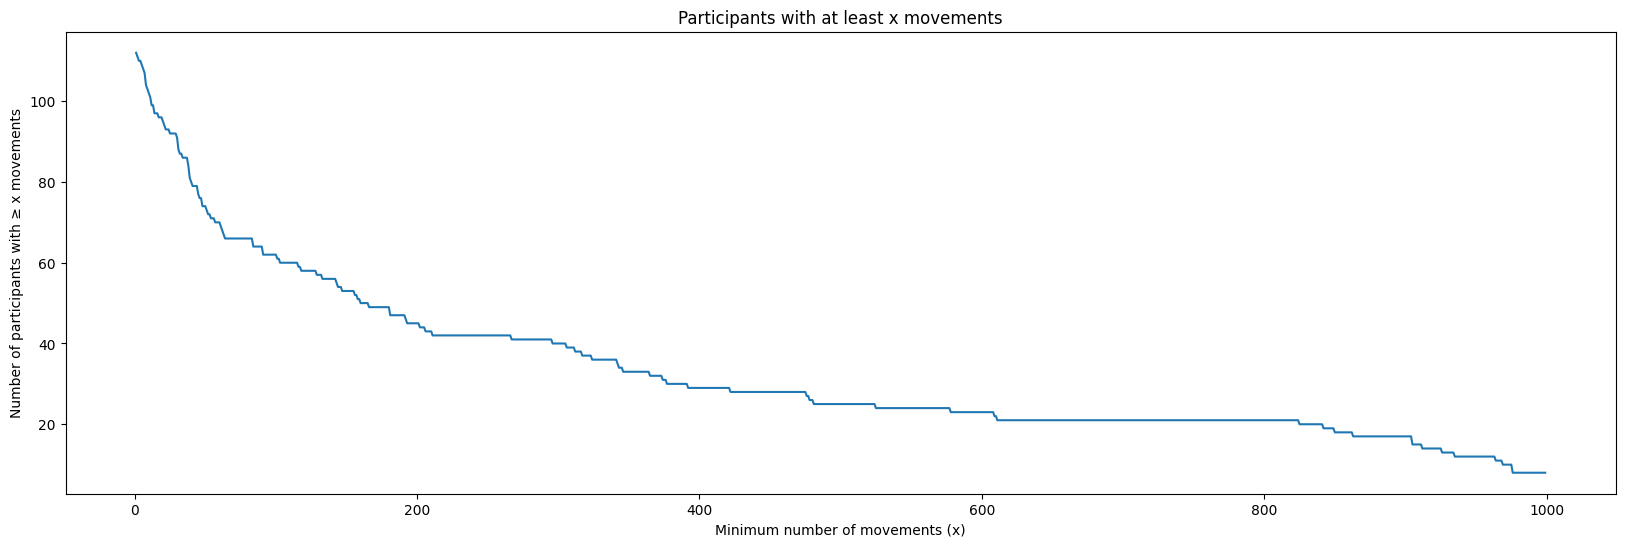

In [14]:
import matplotlib.pyplot as plt

# Count movements per participant
movement_counts = movements['participant_id'].value_counts()

# Sort counts descending
movement_counts = movement_counts.sort_values(ascending=False)

# For each possible threshold x
x_values = range(1, 1000)

participants_with_at_least_x = [
    (movement_counts >= x).sum() for x in x_values
]

plt.figure(figsize=(20, 6))
plt.plot(x_values, participants_with_at_least_x)
plt.xlabel("Minimum number of movements (x)")
plt.ylabel("Number of participants with ≥ x movements")
plt.title("Participants with at least x movements")
plt.show()

In [15]:
# Get date range of movements
min_date = movements["start_time"].min()
max_date = movements["start_time"].max()
print(f"Date range of movements: {min_date} to {max_date}")

Date range of movements: 2024-08-28 06:47:10+00:00 to 2026-02-23 09:13:53+00:00


In [16]:
# Keep only movements with participant_id in lifestyles
movements = movements[movements['participant_id'].isin(lifestyles['participantid'])]

In [17]:
# Get movements length after filtering by lifestyles
print(f"Total movements after filtering by lifestyles: {len(movements)}")

Total movements after filtering by lifestyles: 29231


In [18]:
# Number of unique participants in movements
print(f"Number of unique participants in movements: {movements['participant_id'].nunique()}")

Number of unique participants in movements: 46


In [19]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date
4,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03
5,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03
6,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03
18,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28
19,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28


In [20]:
def fractional_hours(df, start_col="start_time", end_col="end_time"):
    """
    Returns a new DataFrame where each original row is expanded into one row per
    overlapping hour bin, with weight = fraction of that hour occupied.

    Assumes start_time/end_time are timezone-consistent pandas Timestamps.
    Handles trips crossing midnight.
    """
    out_rows = []

    for idx, row in df.iterrows():
        start = row[start_col]
        end = row[end_col]

        if pd.isna(start) or pd.isna(end) or end <= start:
            continue

        # Iterate hour bins from floor(start) to end
        cur = start.floor("h")
        while cur < end:
            bin_start = cur
            bin_end = cur + pd.Timedelta(hours=1)

            overlap_start = max(start, bin_start)
            overlap_end = min(end, bin_end)

            overlap_sec = (overlap_end - overlap_start).total_seconds()
            if overlap_sec > 0:
                new = row.to_dict()
                new["hour_of_day"] = int(bin_start.hour)
                new["weight"] = overlap_sec / 3600.0  # fraction of hour
                out_rows.append(new)

            cur = bin_end

    return pd.DataFrame(out_rows)


In [21]:
# Add corresponding lifestyle to movements
movements = movements.merge(lifestyles[['participantid', 'lifestyle1', 'lifestyle2']], left_on='participant_id', right_on='participantid', how='left')
movements.drop(columns=['participantid'], inplace=True)

In [22]:

movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date,lifestyle1,lifestyle2
0,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03,Sustainable Sam,Modest Mica
1,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03,Sustainable Sam,Modest Mica
2,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03,Sustainable Sam,Modest Mica
3,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28,Sustainable Sam,Modest Mica
4,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28,Sustainable Sam,Modest Mica


Modes of transport: ['Bicycle', 'Bus', 'Car', 'Plane', 'Train', 'Tram', 'Walking']


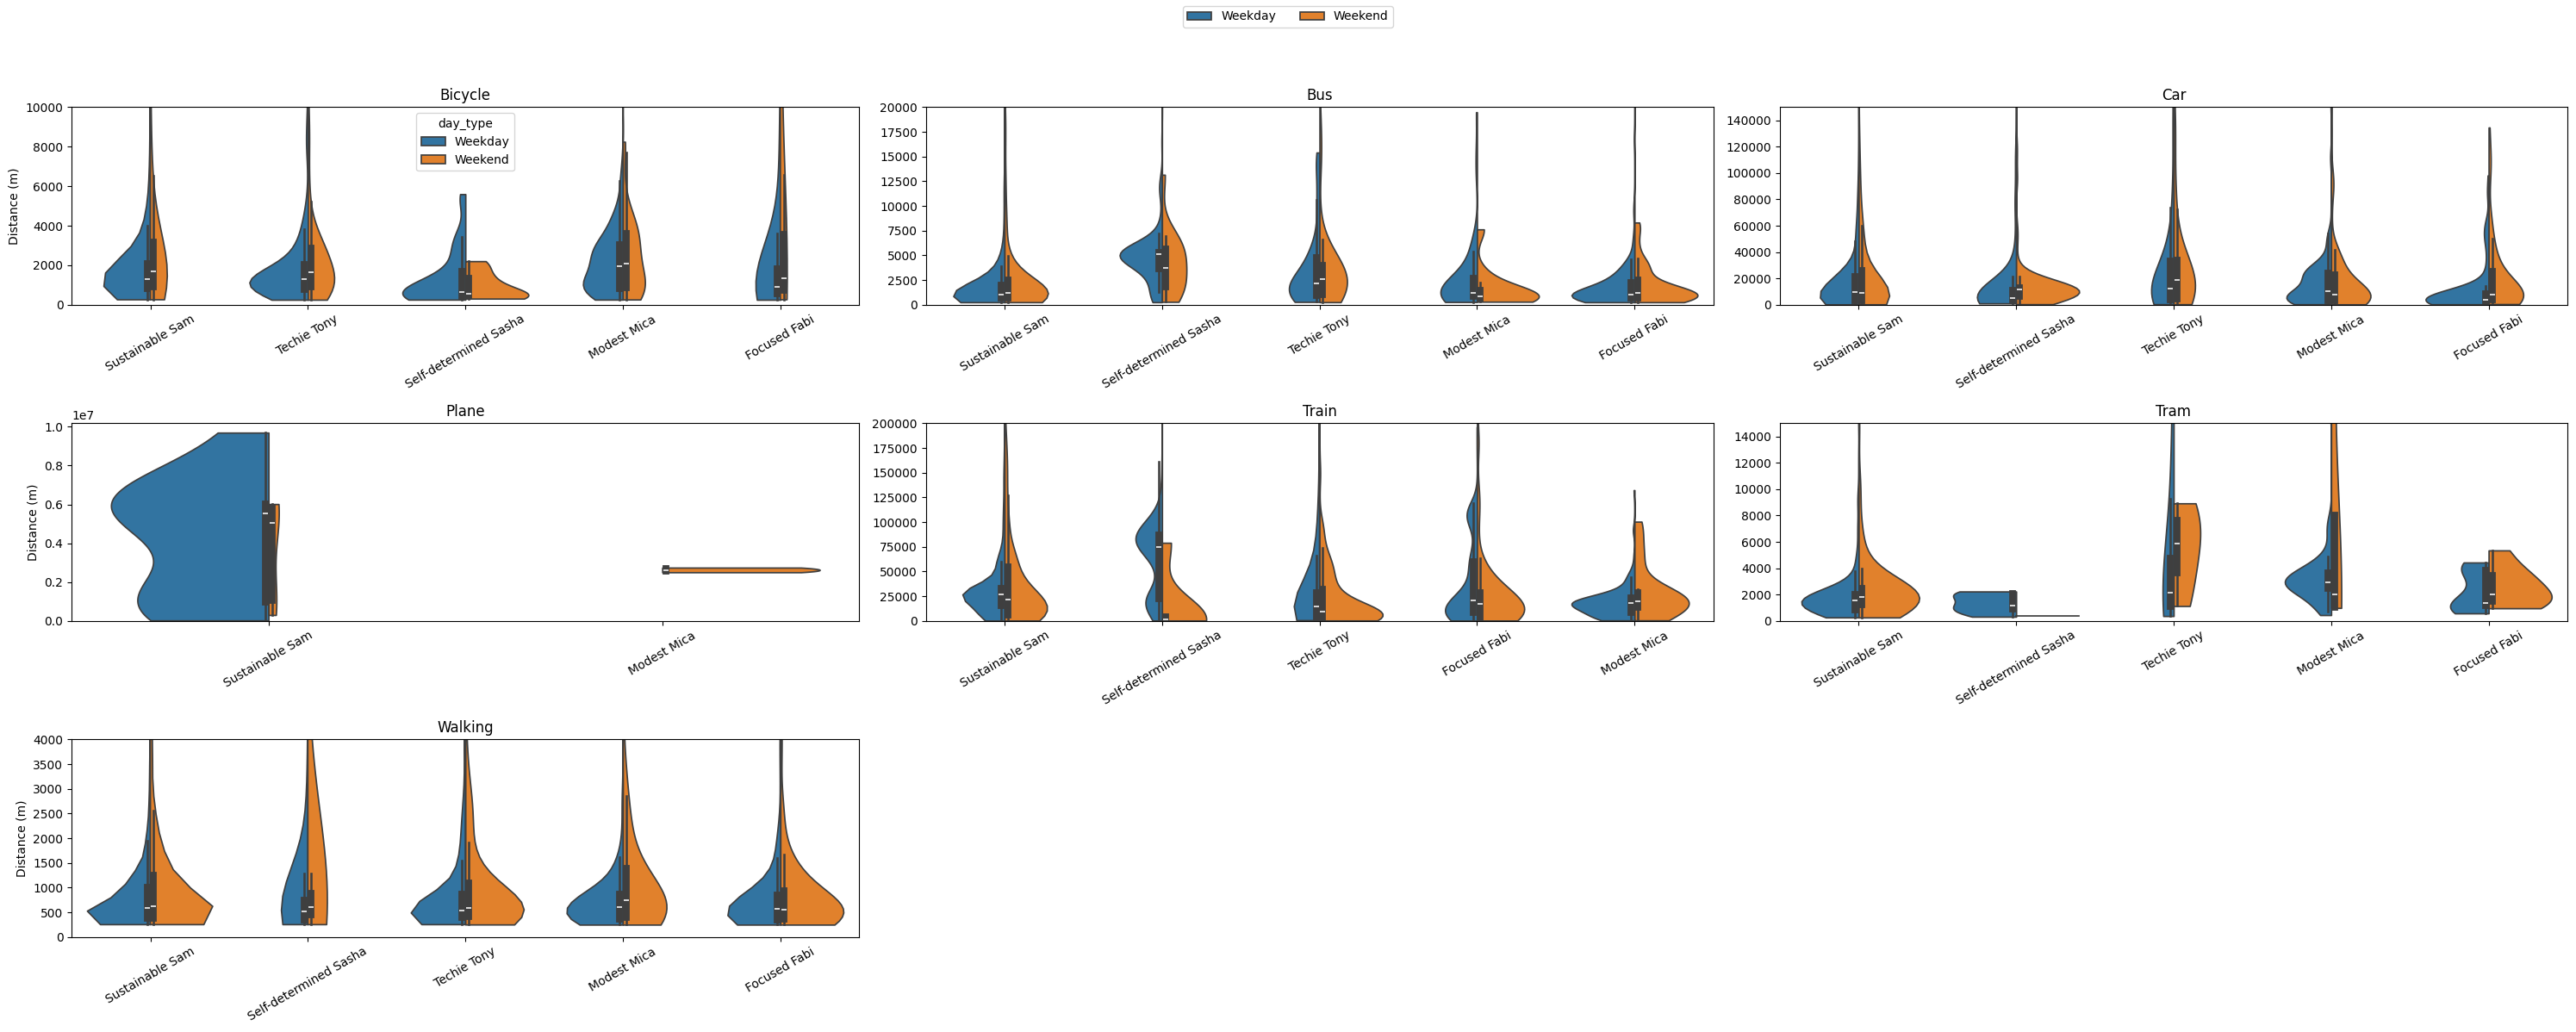

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = movements.copy()  # <-- your raw (not aggregated) dataframe
# Remove Boat and DETECTION_ERROR
df = df[~df["mean_of_transport"].isin(["Boat", "DETECTION_ERROR"])]

# Remvoe walking with more than 40000 meters per day (outliers)
df = df[~((df["mean_of_transport"] == "Walking") & (df["distance(m)"] > 40000))]

# Set limits for y axis to be displayed for each mode of transport
limits = {
    "Walking": 4000,
    "Car": 150000,
    "Bicycle": 10000,
    "Bus": 20000,
    "Tram": 15000,
    "Train": 200000
}

df["day_type"] = np.where(df["is_weekend"], "Weekend", "Weekday")

# optional: drop missing essentials
df = df.dropna(subset=["mean_of_transport", "lifestyle1", "distance(m)", "day_type"])

modes = sorted(df["mean_of_transport"].unique())

print(f"Modes of transport: {modes}")

n = len(modes)

ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols, 4*nrows))#, sharey=True)
axes = np.array(axes).reshape(-1)

for i, mode in enumerate(modes):
    ax = axes[i]
    sub = df[df["mean_of_transport"] == mode]

    # split violins: halves are day_type
    sns.violinplot(
        data=sub,
        x="lifestyle1",
        y="distance(m)",
        hue="day_type",
        split=True,
        cut=0,
        ax=ax
    )

    ax.set_title(mode)
    ax.set_xlabel("")
    ax.set_ylabel("Distance (m)" if i % ncols == 0 else "")
    ax.set_ylim(0, limits.get(mode, None))
    ax.tick_params(axis="x", rotation=30)

    # keep legend only once
    if i != 0:
        ax.get_legend().remove()

# delete unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="", loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [24]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date,lifestyle1,lifestyle2
0,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03,Sustainable Sam,Modest Mica
1,4L5S1E,2024-09-03 17:07:08+00:00,2024-09-03 17:17:04+00:00,u0m709,u0m70f,326,Walking,Walking,0,False,1,False,2024-09-03,Sustainable Sam,Modest Mica
2,4L5S1E,2024-09-03 17:17:05+00:00,2024-09-03 17:24:40+00:00,u0m70f,u0m716,1857,Bus,Bus,245,False,1,False,2024-09-03,Sustainable Sam,Modest Mica
3,119817XU1,2024-08-28 07:38:11+00:00,2024-08-28 07:42:14+00:00,u0qnpk,u0qnpk,254,Walking,Walking,0,False,2,False,2024-08-28,Sustainable Sam,Modest Mica
4,119817XU1,2024-08-28 07:42:15+00:00,2024-08-28 07:44:19+00:00,u0qnpk,u0qnps,598,Bicycle,Bicycle,6,False,2,False,2024-08-28,Sustainable Sam,Modest Mica


In [25]:
# Compute ratio of modes of transport per person by: time, distance, and number of trips (normalized by total trips per lifestyle)

# Ratio by duration of trips:
# Remove DETECTION_ERROR
movements = movements[movements["mean_of_transport"] != "DETECTION_ERROR"]

# COmpute duration of trips in seconds
movements["duration_sec"] = (movements["end_time"] - movements["start_time"]).dt.total_seconds()
# Group by participant_id, lifestyle1, mean_of_transport and sum duration_sec
duration_by_mode = movements.groupby(["participant_id", "lifestyle1", "mean_of_transport"])["duration_sec"].sum().reset_index()

# Set to 0 duration for modes that are not present for a given participant and lifestyle
all_combinations = pd.MultiIndex.from_product([movements["participant_id"].unique(), movements["lifestyle1"].unique(), movements["mean_of_transport"].unique()], names=["participant_id", "lifestyle1", "mean_of_transport"])
duration_by_mode = duration_by_mode.set_index(["participant_id", "lifestyle1", "mean_of_transport"]).reindex(all_combinations, fill_value=0).reset_index()

# Group by participant_id, lifestyle1 and sum duration_sec to get total duration per lifestyle
total_duration = movements.groupby(["participant_id", "lifestyle1"])["duration_sec"].sum().reset_index().rename(columns={"duration_sec": "total_duration_sec"})
# Merge total duration back to duration_by_mode
duration_by_mode = duration_by_mode.merge(total_duration, on=["participant_id", "lifestyle1"])
# Compute ratio of duration per mode
duration_by_mode["duration_ratio"] = duration_by_mode["duration_sec"] / duration_by_mode["total_duration_sec"]
duration_by_mode.head()

,participant_id,lifestyle1,mean_of_transport,duration_sec,total_duration_sec,duration_ratio
0,4L5S1E,Sustainable Sam,Bicycle,1122248.0,6297973.0,0.178192
1,4L5S1E,Sustainable Sam,Walking,1749789.0,6297973.0,0.277834
2,4L5S1E,Sustainable Sam,Bus,220867.0,6297973.0,0.035070
3,4L5S1E,Sustainable Sam,Train,2199939.0,6297973.0,0.349309
4,4L5S1E,Sustainable Sam,Car,608836.0,6297973.0,0.096672


In [26]:
# Compute average, median, and standard deviation of duration_ratio by lifestyle1 and mean_of_transport
duration_stats = duration_by_mode.groupby(["lifestyle1", "mean_of_transport"])["duration_ratio"].agg(["mean", "median", "std"]).reset_index()
duration_stats.head()

,lifestyle1,mean_of_transport,mean,median,std
0,Focused Fabi,Bicycle,0.113029,0.088491,0.092940
1,Focused Fabi,Boat,0.000084,0.000000,0.000188
2,Focused Fabi,Bus,0.046957,0.023983,0.050649
3,Focused Fabi,Car,0.158752,0.142716,0.077824
4,Focused Fabi,Plane,0.000000,0.000000,0.000000


In [27]:
def radar_chart(stats_df, title, value_col="mean"):
    """
    Creates a radar chart comparing lifestyles across modes of transport.
    stats_df should have columns: lifestyle1, mean_of_transport, and the value_col (e.g., mean).
    """
    # Set to 0 the modes that are not present for a lifestyle (e.g., no plane)
    all_modes = stats_df["mean_of_transport"].unique()
    all_lifestyles = stats_df["lifestyle1"].unique()

    # Create a complete DataFrame with all combinations
    complete_df = pd.MultiIndex.from_product([all_lifestyles, all_modes], names=["lifestyle1", "mean_of_transport"]).to_frame(index=False)

    # Merge with filtered durations to get existing values
    pivot = complete_df.merge(stats_df, on=["lifestyle1", "mean_of_transport"], how="left")

    # Fill NaN values with 0
    pivot[value_col] = pivot[value_col].fillna(0)

    # Pivot so each lifestyle is one row
    pivot = pivot.pivot(index="lifestyle1", 
                    columns="mean_of_transport", 
                    values=value_col)

    categories = list(pivot.columns)
    N = len(categories)

    # Sort categories by average across lifestyles
    category_order = pivot.mean().sort_values(ascending=False).index.tolist()
    pivot = pivot[category_order]
    categories = category_order

    # Angles for radar
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the circle

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

    for lifestyle in pivot.index:
        values = pivot.loc[lifestyle].tolist()
        values += values[:1]  # close line
        ax.plot(angles, values, label=lifestyle)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    ax.set_title(title)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

In [28]:
# Do same thing but with distance ratio instead of duration ratio
# Ratio by distance of trips:
# Group by participant_id, lifestyle1, mean_of_transport and sum distance(m)
distance_by_mode = movements.groupby(["participant_id", "lifestyle1", "mean_of_transport"])["distance(m)"].sum().reset_index()

# Set to 0 distance for modes that are not present for a given participant and lifestyle
all_combinations = pd.MultiIndex.from_product([movements["participant_id"].unique(), movements["lifestyle1"].unique(), movements["mean_of_transport"].unique()], names=["participant_id", "lifestyle1", "mean_of_transport"])
distance_by_mode = distance_by_mode.set_index(["participant_id", "lifestyle1", "mean_of_transport"]).reindex(all_combinations, fill_value=0).reset_index()

# Group by participant_id, lifestyle1 and sum distance(m) to get total distance per lifestyle
total_distance = movements.groupby(["participant_id", "lifestyle1"])["distance(m)"].sum().reset_index().rename(columns={"distance(m)": "total_distance(m)"})
# Merge total distance back to distance_by_mode
distance_by_mode = distance_by_mode.merge(total_distance, on=["participant_id", "lifestyle1"])
# Compute ratio of distance per mode
distance_by_mode["distance_ratio"] = distance_by_mode["distance(m)"] / distance_by_mode["total_distance(m)"]
display(distance_by_mode.head())
# Compute average, median, and standard deviation of distance_ratio by lifestyle1 and mean_of_transport
distance_stats = distance_by_mode.groupby(["lifestyle1", "mean_of_transport"])["distance_ratio"].agg(["mean", "median", "std"]).reset_index()
distance_stats.head()

,participant_id,lifestyle1,mean_of_transport,distance(m),total_distance(m),distance_ratio
0,4L5S1E,Sustainable Sam,Bicycle,4931183,80240471,0.061455
1,4L5S1E,Sustainable Sam,Walking,1610823,80240471,0.020075
2,4L5S1E,Sustainable Sam,Bus,1519532,80240471,0.018937
3,4L5S1E,Sustainable Sam,Train,30429279,80240471,0.379226
4,4L5S1E,Sustainable Sam,Car,4493134,80240471,0.055996


,lifestyle1,mean_of_transport,mean,median,std
0,Focused Fabi,Bicycle,0.040046,0.038625,0.027061
1,Focused Fabi,Boat,0.000038,0.000000,0.000085
2,Focused Fabi,Bus,0.037251,0.027077,0.039551
3,Focused Fabi,Car,0.251335,0.222365,0.228980
4,Focused Fabi,Plane,0.000000,0.000000,0.000000


In [29]:
# Compute ratio by total number of trips per lifestyle
# Group by participant_id, lifestyle1, mean_of_transport and count number of trips
trips_by_mode = movements.groupby(["lifestyle1", "mean_of_transport"]).size().reset_index(name="num_trips")
# Group by participant_id, lifestyle1 and count total number of trips per lifestyle
total_trips = movements.groupby(["lifestyle1"]).size().reset_index(name="total_trips")
# Merge total trips back to trips_by_mode
trips_by_mode = trips_by_mode.merge(total_trips, on=["lifestyle1"])
# Compute ratio of trips per mode
trips_by_mode["mean"] = trips_by_mode["num_trips"] / trips_by_mode["total_trips"]
display(trips_by_mode.head())

,lifestyle1,mean_of_transport,num_trips,total_trips,mean
0,Focused Fabi,Bicycle,329,1943,0.169326
1,Focused Fabi,Boat,1,1943,0.000515
2,Focused Fabi,Bus,287,1943,0.147710
3,Focused Fabi,Car,193,1943,0.099331
4,Focused Fabi,Train,376,1943,0.193515


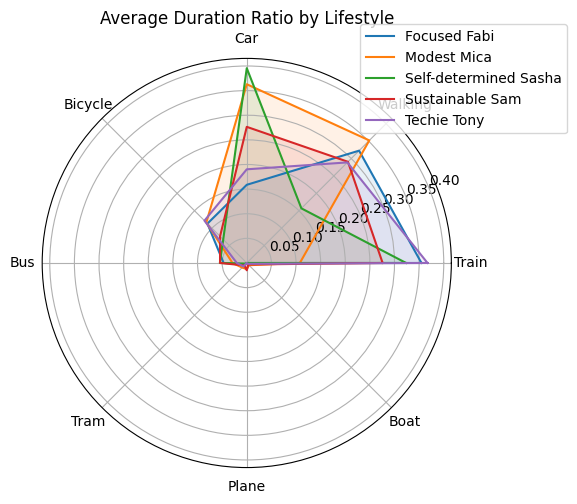

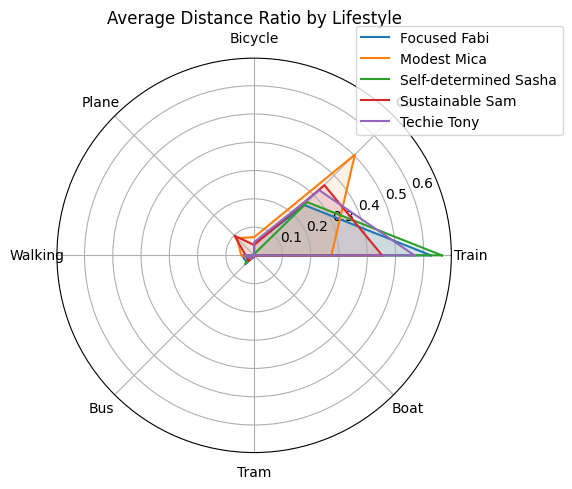

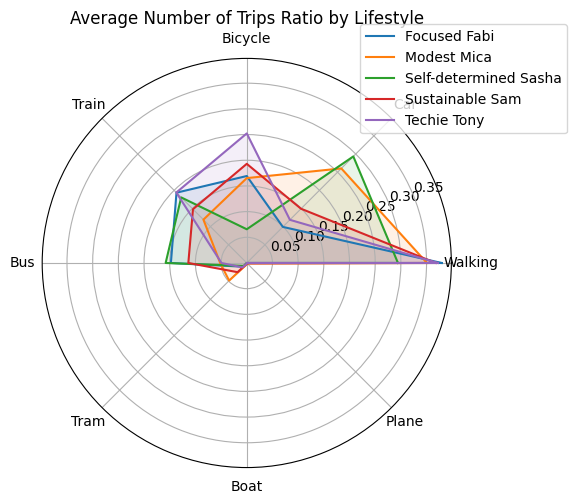

In [30]:
# Radar chart comparing lifestyles across modes of transport by average duration ratio
radar_chart(duration_stats, title="Average Duration Ratio by Lifestyle", value_col="mean")
# Radar chart comparing lifestyles across modes of transport by average distance ratio
radar_chart(distance_stats, title="Average Distance Ratio by Lifestyle", value_col="mean")
# Radar chart comparing lifestyles across modes of transport by average number of trips ratio
radar_chart(trips_by_mode, title="Average Number of Trips Ratio by Lifestyle", value_col="mean")

In [31]:
# Transform movemnets into a list of places visited, where we assume that people stay at a certain location from the end of a movement to the start of the next movement, using end_geohash. Also estimate form when to when a person remained at that location
def movements_to_places(movements):
    places = []
    for participant_id, group in movements.groupby("participant_id"):
        group = group.sort_values("start_time")
        for i in range(len(group) - 1):
            end_geohash = group.iloc[i]["end_geohash"]
            start_time = group.iloc[i]["end_time"]
            end_time = group.iloc[i + 1]["start_time"]
            lifestyle1 = group.iloc[i]["lifestyle1"]

            if pd.isna(end_geohash) or pd.isna(start_time) or pd.isna(end_time):
                continue

            places.append({
                "participant_id": participant_id,
                "lifestyle1": lifestyle1,
                "geohash": end_geohash,
                "start_time": start_time,
                "end_time": end_time
            })

    return pd.DataFrame(places)

places = movements_to_places(movements)

# Compute duration of stay at each place in seconds
places["duration_sec"] = (places["end_time"] - places["start_time"]).dt.total_seconds()

# Remove stays that were longer than 24 hours (possible outliers due to missing movements)
places = places[places["duration_sec"] <= 24 * 3600]

places.head()

,participant_id,lifestyle1,geohash,start_time,end_time,duration_sec
0,0L3S1J,Sustainable Sam,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,28.0
1,0L3S1J,Sustainable Sam,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,1553.0
2,0L3S1J,Sustainable Sam,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,1554.0
3,0L3S1J,Sustainable Sam,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,1.0
4,0L3S1J,Sustainable Sam,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,985.0


In [32]:
# Compute location by hours for each participant (e.g., if places is from 10:02 to 12:45, we create three new lines for that participant: 10:00-11:00, 11:00-12:00, 12:00-13:00 and that location. without weights).
display(places)
places_by_hour = fractional_hours(places, start_col="start_time", end_col="end_time")
places_by_hour = places_by_hour.drop(columns=["weight", "duration_sec"])
display(places_by_hour)

,participant_id,lifestyle1,geohash,start_time,end_time,duration_sec
0,0L3S1J,Sustainable Sam,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,28.0
1,0L3S1J,Sustainable Sam,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,1553.0
2,0L3S1J,Sustainable Sam,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,1554.0
3,0L3S1J,Sustainable Sam,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,1.0
4,0L3S1J,Sustainable Sam,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,985.0
...,...,...,...,...,...,...
29011,9S11M3D,Modest Mica,u0qnq8,2025-07-16 19:26:28+00:00,2025-07-17 05:11:25+00:00,35097.0
29012,9S11M3D,Modest Mica,u0qnnq,2025-07-17 05:19:43+00:00,2025-07-17 15:00:42+00:00,34859.0
29013,9S11M3D,Modest Mica,u0qnxu,2025-07-17 15:25:14+00:00,2025-07-17 16:43:19+00:00,4685.0
29014,9S11M3D,Modest Mica,u0qnnq,2025-07-17 17:00:40+00:00,2025-07-17 19:18:33+00:00,8273.0


,participant_id,lifestyle1,geohash,start_time,end_time,hour_of_day
0,0L3S1J,Sustainable Sam,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,10
1,0L3S1J,Sustainable Sam,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,10
2,0L3S1J,Sustainable Sam,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,12
3,0L3S1J,Sustainable Sam,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,13
4,0L3S1J,Sustainable Sam,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,15
...,...,...,...,...,...,...
120376,9S11M3D,Modest Mica,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,1
120377,9S11M3D,Modest Mica,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,2
120378,9S11M3D,Modest Mica,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,3
120379,9S11M3D,Modest Mica,u0qnq8,2025-07-17 19:23:15+00:00,2025-07-18 05:19:21+00:00,4


In [33]:
# Count occurrence of night time at each location for each participant_id. Then the most visited during the night is home, the most visited durign the day is work and the rest other
night_hours = [22, 23, 0, 1, 2, 3, 4, 5]
day_hours = [9, 10, 11, 12, 13, 14, 15, 16]

night_hours = [22, 23, 0, 1, 2, 3, 4, 5]
day_hours   = [9, 10, 11, 12, 13, 14, 15, 16]

counts_night = (
    places_by_hour[places_by_hour["hour_of_day"].isin(night_hours)]
    .groupby(["participant_id", "geohash"])
    .size()
    .reset_index(name="night_count")
)

counts_day = (
    places_by_hour[places_by_hour["hour_of_day"].isin(day_hours)]
    .groupby(["participant_id", "geohash"])
    .size()
    .reset_index(name="day_count")
)

# Home = argmax night_count per participant
home_locations = (
    counts_night.sort_values(["participant_id", "night_count", "geohash"], ascending=[True, False, True])
    .drop_duplicates("participant_id")
    .rename(columns={"geohash": "home_geohash"})[["participant_id", "home_geohash"]]
)

counts_day_nohome = counts_day.merge(home_locations, on="participant_id", how="left")
counts_day_nohome = counts_day_nohome[(counts_day_nohome["geohash"] != counts_day_nohome["home_geohash"]) | counts_day_nohome["home_geohash"].isna()]

work_locations = (
    counts_day_nohome.sort_values(["participant_id", "day_count", "geohash"], ascending=[True, False, True])
    .drop_duplicates("participant_id")
    .rename(columns={"geohash": "work_geohash"})[["participant_id", "work_geohash"]]
)

display(home_locations.head())
display(work_locations.head())

,participant_id,home_geohash
9,0L3S1J,u0qnnq
15,0Q1Q9Q,u0qj8h
31,10F11M1A,u0m44r
51,10H7K1A,u0qnnq
66,10Z9B1H,u0qnnq


,participant_id,work_geohash
33,0L3S1J,u0qnnm
84,0Q1Q9Q,u0qnnq
164,10F11M1A,u0m44y
270,10H7K1A,u0qq6z
312,10Z9B1H,u0qjex


In [34]:
# Merg the home and work locations in the same dataframe, so that we can map them in pairs on a map
home_work_locations = home_locations.merge(work_locations, on="participant_id", how="outer")

# Find coordinates of home and work geohashes
home_work_locations = home_work_locations.merge(geo_to_coords.rename(columns={"geohash": "home_geohash", "latitude": "home_latitude", "longitude": "home_longitude"}), on="home_geohash", how="left")
home_work_locations = home_work_locations.merge(geo_to_coords.rename(columns={"geohash": "work_geohash", "latitude": "work_latitude", "longitude": "work_longitude"}), on="work_geohash", how="left")

# Add lifestyle1 to home_work_locations
home_work_locations = home_work_locations.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])

display(home_work_locations.head())

,participant_id,home_geohash,work_geohash,home_latitude,home_longitude,work_latitude,work_longitude,lifestyle1
0,0L3S1J,u0qnnq,u0qnnm,47.49664306640625,8.7176513671875,47.49114990234375,8.7176513671875,Sustainable Sam
1,0Q1Q9Q,u0qj8h,u0qnnq,47.39776611328125,8.4429931640625,47.49664306640625,8.7176513671875,Focused Fabi
2,10F11M1A,u0m44r,u0m44y,46.79901123046875,7.1356201171875,46.79351806640625,7.1575927734375,Sustainable Sam
3,10H7K1A,u0qnnq,u0qq6z,47.49664306640625,8.7176513671875,47.54608154296875,8.9154052734375,Sustainable Sam
4,10Z9B1H,u0qnnq,u0qjex,47.49664306640625,8.7176513671875,47.41424560546875,8.5968017578125,Sustainable Sam


In [35]:
# Build map with home-work location pairs, colored by lifestyle1, on a pydeck map. We can use lines to connect home and work locations, and color them by lifestyle1. We can also add points for home and work locations. Let's use arclayer for lines and scatterplotlayer for points.
import pydeck as pdk
import numpy as np

hw = home_work_locations.dropna(
    subset=["home_latitude", "home_longitude", "work_latitude", "work_longitude", "lifestyle1", "participant_id"]
).copy()

# Ensure plain floats
for c in ["home_latitude", "home_longitude", "work_latitude", "work_longitude"]:
    hw[c] = pd.to_numeric(hw[c], errors="coerce")
hw = hw.dropna(subset=["home_latitude", "home_longitude", "work_latitude", "work_longitude"])

# Ensure plain strings/ints (avoid pandas extension dtypes)
hw["participant_id"] = hw["participant_id"].astype(str)
hw["lifestyle1"] = hw["lifestyle1"].astype(str)

# Deterministic RGB colors (plain Python ints)
codes = hw["lifestyle1"].astype("category").cat.codes.to_numpy().astype(np.int32)
rgb = np.stack([
    (37 * codes + 50) % 256,
    (97 * codes + 80) % 256,
    (53 * codes + 110) % 256,
], axis=1).astype(int)

hw["color"] = [list(map(int, row)) for row in rgb]

# Edit color for target location to be red
hw["target_color"] = hw["color"].apply(lambda c: [255, 0, 0])

# Arc positions as plain python floats
hw["source"] = hw[["home_longitude", "home_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)
hw["target"] = hw[["work_longitude", "work_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)

# IMPORTANT: only keep columns that layers/tooltip use (drops any shapely/other objects)
arc_data = hw[["participant_id", "lifestyle1", "color", "target_color", "source", "target"]].to_dict("records")
home_data = hw[["participant_id", "lifestyle1", "color", "target_color",  "home_longitude", "home_latitude"]].to_dict("records")
work_data = hw[["participant_id", "lifestyle1", "color", "target_color", "work_longitude", "work_latitude"]].to_dict("records")

deck = pdk.Deck(
    initial_view_state=pdk.ViewState(latitude=46.8, longitude=8.3, zoom=7, pitch=0),
    layers=[
        pdk.Layer(
            "ArcLayer",
            data=arc_data,
            get_source_position="source",
            get_target_position="target",
            get_source_color="color",
            get_target_color="target_color",
            get_width=2,
            pickable=True,
            get_height=0.5
        ),
        pdk.Layer(
            "ScatterplotLayer",
            data=home_data,
            get_position=["home_longitude", "home_latitude"],
            get_fill_color="color",
            get_radius=120,
            pickable=True,
        ),
        pdk.Layer(
            "ScatterplotLayer",
            data=work_data,
            get_position=["work_longitude", "work_latitude"],
            get_fill_color="target_color",
            get_radius=40,
            pickable=True,
        ),
    ],
    tooltip={"text": "id: {participant_id}\nlifestyle: {lifestyle1}"},
)

deck.to_html("maps/home_work_locations_map.html")
! open maps/home_work_locations_map.html



/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_93041/666758857.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hw["source"] = hw[["home_longitude", "home_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)
/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_93041/666758857.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hw["target"] = hw[["work_longitude", "work_latitude"]].apply(lambda r: [float(r[0]), float(r[1])], axis=1)


In [42]:
# Get coordinates for all places:
# If needed: attach lat/lon to every place observation
places = places_by_hour.merge(geo_to_coords, on="geohash", how="left").dropna(subset=["latitude","longitude"])
display(places.head())

,participant_id,lifestyle1,geohash,start_time,end_time,hour_of_day,latitude,longitude
0,0L3S1J,Sustainable Sam,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,10,47.50213623046875,8.7176513671875
1,0L3S1J,Sustainable Sam,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,10,47.37579345703125,8.5418701171875
2,0L3S1J,Sustainable Sam,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,12,47.04620361328125,9.4427490234375
3,0L3S1J,Sustainable Sam,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,13,46.81549072265625,9.3548583984375
4,0L3S1J,Sustainable Sam,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,15,46.80450439453125,9.3109130859375


In [43]:
# Compute duration of stay at each place in seconds
places["duration_sec"] = (places["end_time"] - places["start_time"]).dt.total_seconds()
# Remove stays that were longer than 48 hours (possible outliers due to missing movements)
places_filtered = places[places["duration_sec"] <= 48 * 3600]
display(places_filtered.head())

,participant_id,lifestyle1,geohash,start_time,end_time,hour_of_day,latitude,longitude,duration_sec
0,0L3S1J,Sustainable Sam,u0qnnr,2025-05-23 10:02:25+00:00,2025-05-23 10:02:53+00:00,10,47.50213623046875,8.7176513671875,28.0
1,0L3S1J,Sustainable Sam,u0qjd2,2025-05-23 10:30:21+00:00,2025-05-23 10:56:14+00:00,10,47.37579345703125,8.5418701171875,1553.0
2,0L3S1J,Sustainable Sam,u0qewu,2025-05-23 12:00:42+00:00,2025-05-23 12:26:36+00:00,12,47.04620361328125,9.4427490234375,1554.0
3,0L3S1J,Sustainable Sam,u0qdkf,2025-05-23 13:13:57+00:00,2025-05-23 13:13:58+00:00,13,46.81549072265625,9.3548583984375,1.0
4,0L3S1J,Sustainable Sam,u0qd7b,2025-05-23 15:04:36+00:00,2025-05-23 15:21:01+00:00,15,46.80450439453125,9.3109130859375,985.0


In [44]:
import numpy as np
import pandas as pd
from pyproj import Transformer

# Compute the RADIUS OF GYRATION for each participant, which is a measure of the spatial spread of their visited locations. It is defined as the root mean square distance of the visited locations from their center of mass (average location). We will compute it in meters, so we need to transform the lat/lon coordinates to a projected coordinate system (e.g., Swiss LV95) before computing distances.
# Normalize the radius of gyration by the time spent at each location

WGS84_TO_LV95 = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)

def radius_of_gyration(group: pd.DataFrame) -> float:
    lon = group["longitude"].to_numpy(float)
    lat = group["latitude"].to_numpy(float)
    x, y = WGS84_TO_LV95.transform(lon, lat)

    x = np.asarray(x, float); y = np.asarray(y, float)
    if len(x) < 2:
        return np.nan

    x_cm = x.mean()
    y_cm = y.mean()
    rg = np.sqrt(np.mean((x - x_cm)**2 + (y - y_cm)**2))
    return float(rg)

def daily_rg(
    places: pd.DataFrame,
    id_col: str = "participant_id",
    time_col: str = "timestamp",   # change if needed
    lat_col: str = "latitude",
    lon_col: str = "longitude",
    tz: str = "Europe/Zurich",
    min_points_per_day: int = 2,
) -> pd.DataFrame:
    df = places.copy()

    # Parse timestamps and convert to local date
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[id_col, time_col, lat_col, lon_col])

    df["local_time"] = df[time_col].dt.tz_convert(tz)
    df["date"] = df["local_time"].dt.floor("D")
    df["is_weekend"] = df["local_time"].dt.weekday.isin([5, 6])

    # Ensure numeric coords
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df = df.dropna(subset=[lat_col, lon_col])

    # Project to LV95 meters (vectorized for all rows)
    x, y = WGS84_TO_LV95.transform(df[lon_col].to_numpy(float), df[lat_col].to_numpy(float))
    df["x"] = np.asarray(x, float)
    df["y"] = np.asarray(y, float)

    def _rg(g: pd.DataFrame) -> float:
        xy = g[["x", "y"]].to_numpy(float)
        if len(xy) < min_points_per_day:
            return np.nan
        x_cm = xy[:, 0].mean()
        y_cm = xy[:, 1].mean()
        return float(np.sqrt(np.mean((xy[:, 0] - x_cm) ** 2 + (xy[:, 1] - y_cm) ** 2)))

    rg_daily = (
        df.groupby([id_col, "date"], sort=False)
          .apply(_rg)
          .reset_index(name="rg_m")
    )

    # add weekend flag + count of points used
    pts_n = df.groupby([id_col, "date"], sort=False).size().reset_index(name="n_points")
    wknd = df.groupby([id_col, "date"], sort=False)["is_weekend"].first().reset_index()

    rg_daily = rg_daily.merge(pts_n, on=[id_col, "date"], how="left").merge(wknd, on=[id_col, "date"], how="left")
    return rg_daily.sort_values([id_col, "date"]).reset_index(drop=True)

# Usage:
# rg_daily = daily_rg(places, time_col="timestamp")  # adapt time_col if needed
# display(rg_daily.head())



rg_daily = daily_rg(places, time_col="start_time")  # adapt time_col if needed

rg_per_person = (
    places.groupby("participant_id")
    .apply(radius_of_gyration)
    .reset_index(name="rg_m")
)

display(rg_daily.head())
display(rg_per_person.head())

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_33141/1066410301.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_rg)
/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_33141/1066410301.py:84: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(radius_of_gyration)


,participant_id,date,rg_m,n_points,is_weekend
0,0L3S1J,2025-05-23 00:00:00+02:00,25594.478627,26,False
1,0L3S1J,2025-05-24 00:00:00+02:00,NaN,1,True
2,0L3S1J,2025-05-26 00:00:00+02:00,8226.877920,31,False
3,0L3S1J,2025-05-27 00:00:00+02:00,323.543436,29,False
4,0L3S1J,2025-05-28 00:00:00+02:00,359.982017,7,False


,participant_id,rg_m
0,0L3S1J,763808.304702
1,0Q1Q9Q,85833.858675
2,10F11M1A,230311.414781
3,10H7K1A,28483.073898
4,10Z9B1H,22106.444175


In [45]:
# Show the people with the biggest radius of gyration (most spatially spread out)
display(rg_per_person.sort_values("rg_m", ascending=False).head(10))
display(rg_daily.sort_values("rg_m", ascending=False).head(10))

,participant_id,rg_m
33,6T2PXJ,2.270790e+06
22,4L5S1E,1.727683e+06
36,7Z6L2F,1.483512e+06
5,119817XU1,1.154660e+06
39,8G2B2C,8.495409e+05
0,0L3S1J,7.638083e+05
16,2W12R1D,6.504365e+05
23,4T11G3A,4.182706e+05
35,7F3MXU,3.719995e+05
19,3K9V1H,2.390096e+05


,participant_id,date,rg_m,n_points,is_weekend
1523,4L5S1E,2024-11-28 00:00:00+01:00,4.502169e+06,10,False
1505,4L5S1E,2024-11-08 00:00:00+01:00,3.774228e+06,31,False
1609,4L5S1E,2025-03-03 00:00:00+01:00,3.281567e+06,32,False
1476,4L5S1E,2024-10-05 00:00:00+02:00,3.061873e+06,13,True
1446,4L5S1E,2024-09-04 00:00:00+02:00,2.725679e+06,20,False
3562,7Z6L2F,2025-06-15 00:00:00+02:00,2.562850e+06,22,True
3799,8G2B2C,2024-11-19 00:00:00+01:00,2.139116e+06,28,False
1080,2W12R1D,2025-06-22 00:00:00+02:00,1.187445e+06,40,True
1151,2W12R1D,2025-09-13 00:00:00+02:00,9.866024e+05,20,True
3157,6T2PXJ,2025-07-10 00:00:00+02:00,8.359499e+05,22,False


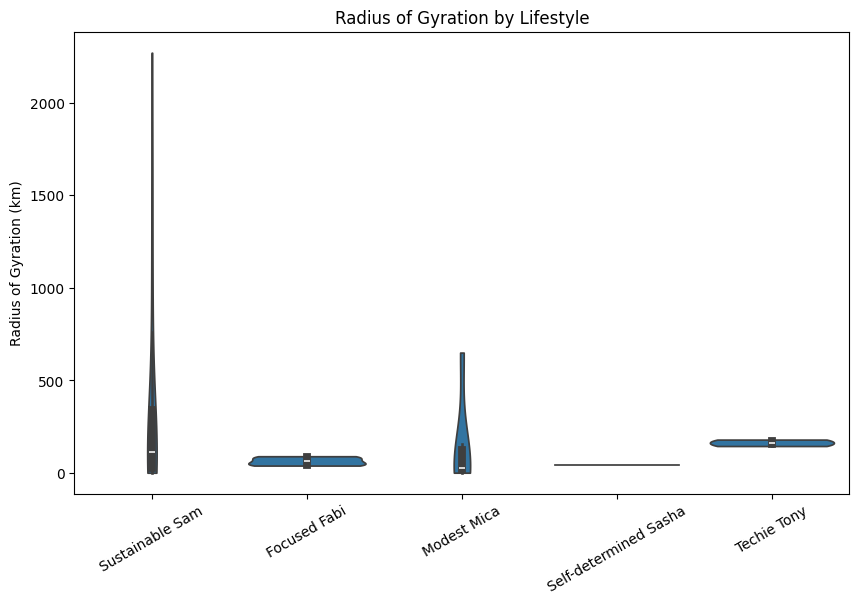

In [46]:
# Plot radius of gyration in km by lifestyle1 (violin plot)
rg_per_person_km = rg_per_person.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])
rg_per_person_km["rg_km"] = rg_per_person_km["rg_m"] / 1000 # convert to km for better readability

plt.figure(figsize=(10,6))
sns.violinplot(data=rg_per_person_km, x="lifestyle1", y="rg_km", cut=0)
plt.title("Radius of Gyration by Lifestyle")
plt.xlabel("")
plt.ylabel("Radius of Gyration (km)")
plt.xticks(rotation=30)
plt.show()

In [47]:
rg_daily.head()

,participant_id,date,rg_m,n_points,is_weekend
0,0L3S1J,2025-05-23 00:00:00+02:00,25594.478627,26,False
1,0L3S1J,2025-05-24 00:00:00+02:00,NaN,1,True
2,0L3S1J,2025-05-26 00:00:00+02:00,8226.877920,31,False
3,0L3S1J,2025-05-27 00:00:00+02:00,323.543436,29,False
4,0L3S1J,2025-05-28 00:00:00+02:00,359.982017,7,False


/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_33141/2490899342.py:13: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=median_rg_per_person, x="lifestyle1", y="median_rg_km", cut=0, hue="is_weekend", split=True, inner="quartile", scale="width")


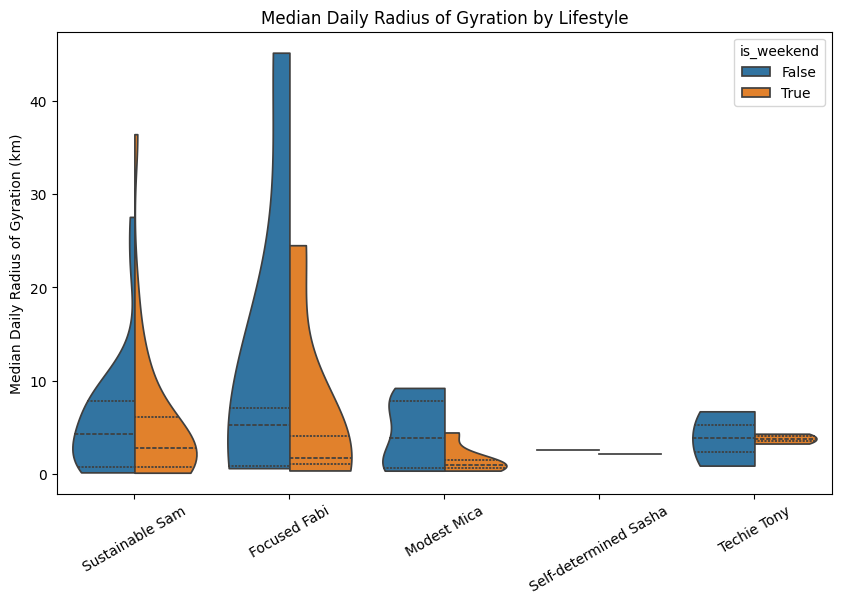

In [48]:
# Get median radius of gyration per person
median_rg_per_person = (
    rg_daily.groupby(["participant_id", "is_weekend"])["rg_m"].median().reset_index(name="median_rg_m")
)

# Merge with lifestyles
median_rg_per_person = median_rg_per_person.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])

# Plot median radius of gyration by lifestyle1 (violin plot)
median_rg_per_person["median_rg_km"] = median_rg_per_person["median_rg_m"] / 1000 # convert to km for better readability

plt.figure(figsize=(10,6))
sns.violinplot(data=median_rg_per_person, x="lifestyle1", y="median_rg_km", cut=0, hue="is_weekend", split=True, inner="quartile", scale="width")
plt.title("Median Daily Radius of Gyration by Lifestyle")
plt.xlabel("")
plt.ylabel("Median Daily Radius of Gyration (km)")
plt.xticks(rotation=30)
plt.show()

In [49]:
homes = home_locations.merge(
    geo_to_coords.rename(columns={"geohash":"home_geohash", "latitude":"home_lat", "longitude":"home_lon"}),
    on="home_geohash", how="left"
)

places2 = places.merge(homes[["participant_id","home_lat","home_lon"]], on="participant_id", how="left")

# project both points and home to meters
lon = places2["longitude"].to_numpy(float)
lat = places2["latitude"].to_numpy(float)
hx  = places2["home_lon"].to_numpy(float)
hy  = places2["home_lat"].to_numpy(float)

x, y   = WGS84_TO_LV95.transform(lon, lat)
x0, y0 = WGS84_TO_LV95.transform(hx,  hy)

places2["dist_from_home_m"] = np.sqrt((np.asarray(x)-np.asarray(x0))**2 + (np.asarray(y)-np.asarray(y0))**2)

home_dispersion = (
    places2.groupby("participant_id")["dist_from_home_m"]
    .agg(mean_home_m="mean", p90_home_m=lambda s: np.nanpercentile(s.to_numpy(float), 90), max_home_m="max")
    .reset_index()
)

display(home_dispersion.head())

,participant_id,mean_home_m,p90_home_m,max_home_m
0,0L3S1J,300999.773071,952096.759075,2.909827e+06
1,0Q1Q9Q,46977.639194,266823.893612,2.713578e+05
2,10F11M1A,77759.150518,299430.712099,8.866817e+05
3,10H7K1A,17236.330856,66284.174571,1.495268e+05
4,10Z9B1H,17620.200405,39118.260134,4.366452e+04


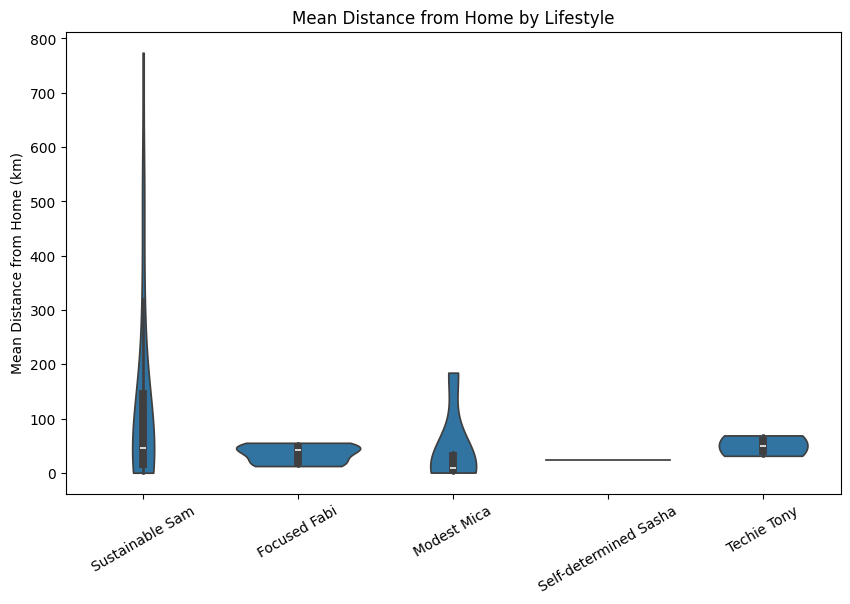

In [50]:
# Plot mean_home_m by lifestyle1 (violin plot)
home_dispersion = home_dispersion.merge(lifestyles[['participantid', 'lifestyle1']], left_on='participant_id', right_on='participantid', how='left').drop(columns=['participantid'])
home_dispersion["mean_home_km"] = home_dispersion["mean_home_m"] / 1000 # convert to km for better readability
plt.figure(figsize=(10,6))
sns.violinplot(data=home_dispersion, x="lifestyle1", y="mean_home_km", cut=0)
plt.title("Mean Distance from Home by Lifestyle")
plt.xlabel("")
plt.ylabel("Mean Distance from Home (km)")
plt.xticks(rotation=30)
plt.show()

In [51]:
steps.head()

,participant_id,day,steps
0,219935XE1,2024-08-28,4179
1,219935XE1,2024-08-28,3992
2,219935XE1,2024-08-29,5254
3,219935XE1,2024-08-29,3017
4,219935XE1,2024-08-30,5837


In [52]:
lifestyles.head()

,participantid,lifestyle1,lifestyle2
0,4L5S1E,Sustainable Sam,Modest Mica
1,9U7Q9K,Sustainable Sam,Bon vivant Bobbie
2,8G2B2C,Sustainable Sam,Modest Mica
3,6F10L1F,Sustainable Sam,Modest Mica
4,10F11M1A,Sustainable Sam,Techie Tony


In [53]:
# Same but with number of steps per day instead of distance

# Add lifestyle1 and lifestyle2 to steps
steps = steps.merge(lifestyles[['participantid', 'lifestyle1', 'lifestyle2']], left_on='participant_id', right_on='participantid', how='left')
steps.drop(columns=['participantid'], inplace=True)

In [54]:
# Remove steps with missing lifestyle1 or lifestyle2
steps = steps.dropna(subset=['lifestyle1', 'lifestyle2'])

# Add day_type to steps, checking if the day is weekend or weekday based on date
steps['day'] = pd.to_datetime(steps['day'], errors='coerce')
steps['dow'] = steps['day'].dt.day_of_week
steps['is_weekend'] = steps['dow'].isin([5,6])

steps.head()

,participant_id,day,steps,lifestyle1,lifestyle2,dow,is_weekend
10,4L5S1E,2024-08-28,3992,Sustainable Sam,Modest Mica,2,False
11,4L5S1E,2024-08-29,3017,Sustainable Sam,Modest Mica,3,False
12,4L5S1E,2024-08-30,0,Sustainable Sam,Modest Mica,4,False
13,4L5S1E,2024-08-31,0,Sustainable Sam,Modest Mica,5,True
14,4L5S1E,2024-09-01,0,Sustainable Sam,Modest Mica,6,True


In [55]:
# Remove data with 0 steps
steps = steps[steps['steps'] > 0]

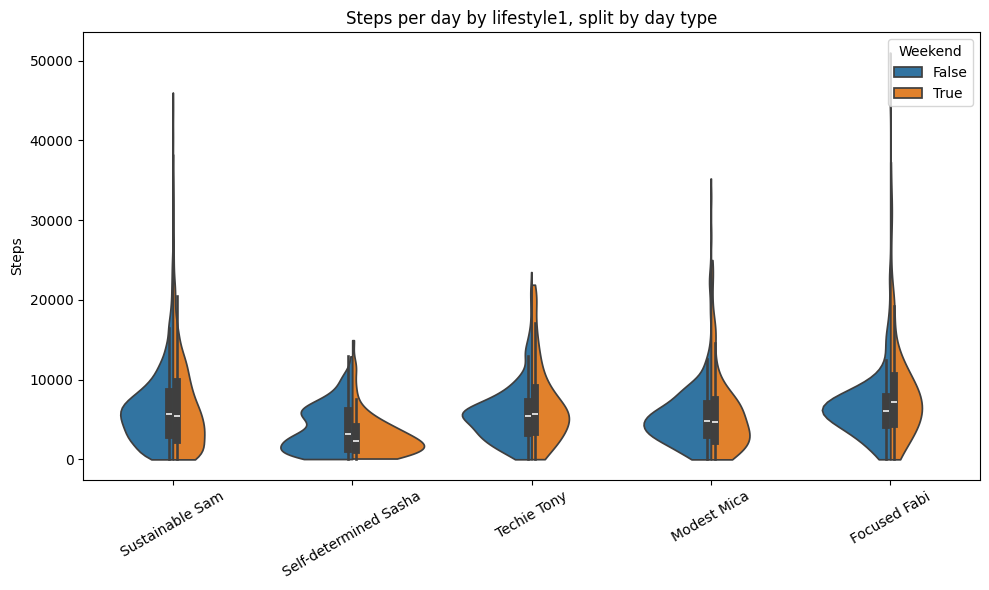

In [56]:
# Plot days per lifestyle1, split by day_type (weekend vs weekday) in a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=steps,
    x="lifestyle1",
    y="steps",
    hue="is_weekend",
    split=True,
    cut=0
)

plt.title("Steps per day by lifestyle1, split by day type")
plt.xlabel("")
plt.ylabel("Steps")
plt.xticks(rotation=30)
plt.legend(title="Weekend", loc="upper right")
plt.tight_layout()
plt.show()